In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ast


In [150]:
filepath = "./simulation_data_2_particles.csv"
df = pd.read_csv(filepath)

In [151]:
len(df)

1000000

In [130]:
df.head()

,simulation_id,time,x,V
0,0,0.000,"[0.3444218515250481, 0.2579544029403025]",0.434626
1,0,0.001,"[0.3444218515250481, 0.2579544029403025]",0.434626
2,0,0.002,"[0.3444171898388335, 0.2579590646265171]",0.434583
3,0,0.003,"[0.34440786646640426, 0.25796838799894634]",0.434496
4,0,0.004,"[0.3443938816408447, 0.25798237282450587]",0.434366


In [127]:
df.head()

,simulation_id,time,x,V
0,0,0.000,"[0.3444218515250481, 0.2579544029403025]",0.434626
1,0,0.001,"[0.3444218515250481, 0.2579544029403025]",0.434626
2,0,0.002,"[0.3444171898388335, 0.2579590646265171]",0.434583
3,0,0.003,"[0.34440786646640426, 0.25796838799894634]",0.434496
4,0,0.004,"[0.3443938816408447, 0.25798237282450587]",0.434366


In [ ]:
import numpy as np


y

array([1.69074275, 1.21469552, 0.28030348, 1.08081122, 1.6757438 ,
       0.85846523, 1.0237715 , 1.03228656, 1.18094163, 1.40784586])

In [ ]:
x = np.random.random([1000, 2])
y = x[:, 0] + x[:, 1]


df = pd.DataFrame({"x": x.tolist(), "V": y.tolist()})
print(df.head())
df.to_csv("x1_plus_x2.csv")

                                            x         V
0    [0.7344668536693836, 0.8581842999809742]  1.592651
1  [0.47855892244418097, 0.11085335059480583]  0.589412
2  [0.32216526761122743, 0.08283710838772484]  0.405002
3   [0.6945998532983152, 0.44092430540979466]  1.135524
4     [0.406014284634745, 0.2627914921111705]  0.668806


In [149]:
x = np.random.random([1000, 2])
y = x[:, 0] * x[:, 1]


df = pd.DataFrame({"x": x.tolist(), "V": y.tolist()})
print(df.head())
df.to_csv("x1_times_x2.csv")

                                            x         V
0   [0.34228086749973474, 0.7912327380528538]  0.270824
1    [0.6348544837662858, 0.7589281159994196]  0.481809
2    [0.8845450609046112, 0.9357591581181693]  0.827721
3  [0.04822107597540093, 0.06427465406249044]  0.003099
4   [0.23953688674817142, 0.7543241462266298]  0.180688


In [140]:
x

array([[0.76910303, 0.92163972],
       [0.46098158, 0.75371394],
       [0.01221767, 0.2680858 ],
       [0.27305841, 0.80775281],
       [0.89078771, 0.7849561 ],
       [0.33431616, 0.52414907],
       [0.13047654, 0.89329496],
       [0.65328598, 0.37900058],
       [0.50270146, 0.67824017],
       [0.78500564, 0.62284021]])

In [122]:

def create_simulation_video(df, simulation_id, frames, path_prefix):
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    fig, ax = plt.subplots()
    scat = ax.scatter([], [], s=80)

    ax.set_xlim(-1, 1)   
    ax.set_ylim(-0.2, 0.2)  
    ax.set_yticks([])

    def init():
        scat.set_offsets(np.empty((0, 2)))
        return (scat,)

    def update(frame):
        xs = ast.literal_eval(df[df["simulation_id"] == simulation_id]['x'].iloc[frame])
        # print('xs', xs)
        ys = [0] * len(xs)
        scat.set_offsets(np.c_[xs, ys])
        scat.set_facecolors(colors[:len(xs)])
        return (scat,)

    ani = FuncAnimation(fig, update, frames=frames,
                                init_func=init, blit=True, interval=20)

    ani.save(path_prefix + "_"+ str(simulation_id) +".mp4", writer="ffmpeg", fps=30)

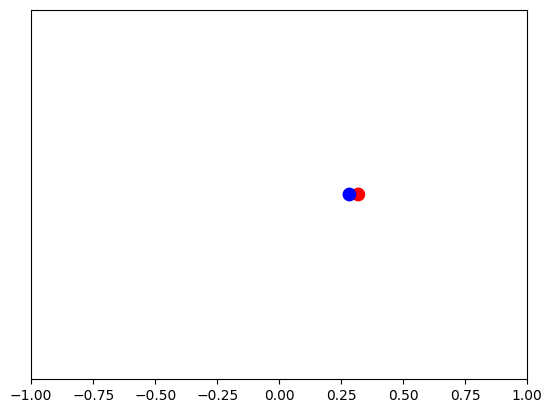

In [126]:
create_simulation_video(df, 0, 1000, "./simulations/two_particle_sim")

In [105]:
# for i in range(2):
#     create_simulation_video(df, i, 1000, "./simulations/two_particle_sim")

In [108]:
def plot_graph(df, simulation_id):

    positions = [ast.literal_eval(pos) for pos in df[df["simulation_id"] == simulation_id]['x'].tolist()]
    t = list(range(len(positions)))
    print('positions', positions)

    p0_positions = [el[0] for el in positions]
    p1_positions = [el[1] for el in positions]
    print(p0_positions)

    plt.plot(t, p0_positions, label="Particle 0")
    plt.plot(t, p1_positions, label="Particle 1")
    plt.xlabel("Time")
    plt.ylabel("xs")
    plt.legend()
    plt.show()



positions [[0.3444218515250481, 0.2579544029403025], [0.3444218515250481, 0.2579544029403025], [0.3444171898388335, 0.2579590646265171], [0.34440786646640426, 0.25796838799894634], [0.3443938816408447, 0.25798237282450587], [0.34437523582832347, 0.2580010186370271], [0.3443519297280818, 0.2580243247372688], [0.3443239642724104, 0.2580522901929402], [0.3442913406266142, 0.2580849138387364], [0.34425406018896604, 0.25812219427638455], [0.34421212459064815, 0.25816412987470244], [0.3441655356956825, 0.2582107187696681], [0.3441142956008489, 0.2582619588645017], [0.3440584066355921, 0.2583178478297585], [0.34399787136191695, 0.25837838310343364], [0.34393269257427167, 0.2584435618910789], [0.3438628732994199, 0.2585133811659307], [0.34378841679630107, 0.2585878376690495], [0.3437093265558789, 0.2586669279094717], [0.34362560630097855, 0.25875064816437204], [0.343537259986112, 0.2588389944792386], [0.3434442917972921, 0.2589319626680585], [0.3433467061518345, 0.2590295483135161], [0.3432445

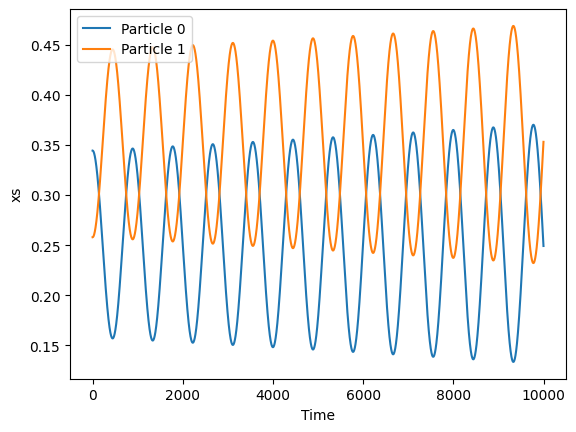

positions [[-0.079428419169155, -0.24108324970703665], [-0.079428419169155, -0.24108324970703665], [-0.07943496053991844, -0.2410767083362732], [-0.07944804328144534, -0.2410636255947463], [-0.07946766706666714, -0.2410440018095245], [-0.07949383124144677, -0.24101783763474488], [-0.07952653482459497, -0.24098513405159666], [-0.07956577650790302, -0.24094589236828862], [-0.07961155465619173, -0.2409001142199999], [-0.07966386730737696, -0.2408478015688147], [-0.07972271217255128, -0.24078895670364037], [-0.07978808663608214, -0.2407235822401095], [-0.07985998775572627, -0.24065168112046537], [-0.0799384122627605, -0.24057325661343112], [-0.08002335656212885, -0.24048831231406279], [-0.08011481673260597, -0.24039685214358567], [-0.08021278852697689, -0.24029888034921476], [-0.08031726737223308, -0.24019440150395857], [-0.08042824836978482, -0.24008342050640682], [-0.08054572629568986, -0.23996594258050177], [-0.08066969560089832, -0.23984197327529333], [-0.0808001504115139, -0.239711518

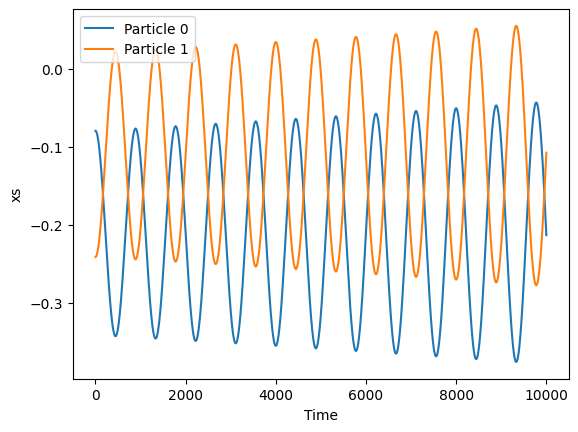

positions [[0.01127472136860852, -0.09506586254958571], [0.01127472136860852, -0.09506586254958571], [0.011269562854010566, -0.09506070403498776], [0.011259245824814657, -0.09505038700579185], [0.011243770538946523, -0.09503491171992372], [0.011223137512257623, -0.09501427869323482], [0.011197347518512252, -0.09498848869948945], [0.011166401589361743, -0.09495754277033894], [0.011130301014305784, -0.09492144219528298], [0.011089047340640833, -0.09488018852161803], [0.011042642373395641, -0.09483378355437284], [0.010991088175253893, -0.0947822293562311], [0.010934387066463951, -0.09472552824744115], [0.010872541624735723, -0.09466368280571293], [0.010805554685124646, -0.09459669586610185], [0.010733429339902808, -0.09452457052088001], [0.01065616893841719, -0.09444731011939439], [0.010573777086935052, -0.09436491826791225], [0.01048625764847647, -0.09427739882945367], [0.010393614742634014, -0.09418475592361121], [0.010295852745379612, -0.0940869939263568], [0.010192976288858553, -0.093

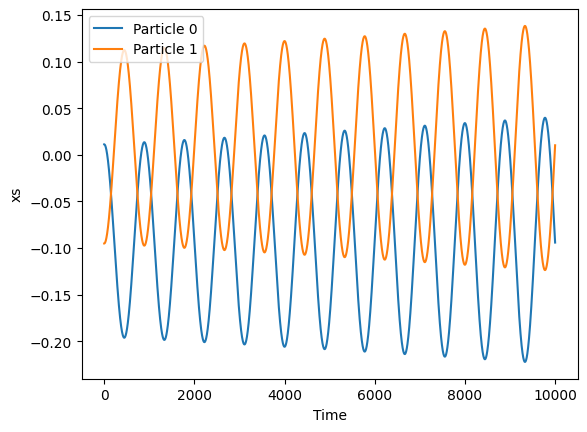

positions [[0.2837985890347726, -0.19668727392107255], [0.2837985890347726, -0.19668727392107255], [0.28378407688819873, -0.19667276177449866], [0.28375505259505096, -0.19664373748135086], [0.2837115168809366, -0.1966002017672365], [0.28365347119707035, -0.19654215608337022], [0.28358091772023786, -0.19646960260653776], [0.28349385935272337, -0.19638254423902327], [0.2833922997222007, -0.1962809846085006], [0.2832762431815882, -0.19616492806788816], [0.28314569480886753, -0.19603437969516743], [0.28300066040686556, -0.19588934529316548], [0.282841146503001, -0.19572983138930092], [0.282667160348994, -0.19555584523529387], [0.28247870992053964, -0.1953673948068395], [0.2822758039169457, -0.19516448880324555], [0.2820584517607335, -0.1949471366470334], [0.2818266635972034, -0.19471534848350325], [0.281580450293963, -0.1944691351802629], [0.2813198234404206, -0.19420850832672054], [0.28104479534724136, -0.19393348023354132], [0.28075537904576797, -0.1936440639320679], [0.2804515882874051,

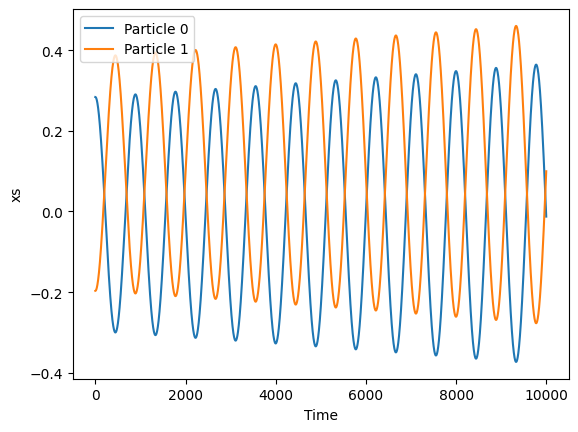

positions [[-0.02340304584764419, 0.0833820394550312], [-0.02340304584764419, 0.0833820394550312], [-0.023402876220511622, 0.08338186982789864], [-0.023402536966246487, 0.0833815305736335], [-0.023402028093330144, 0.08338102170071715], [-0.023401349618725302, 0.0833803432261123], [-0.02340050156787561, 0.08337949517526261], [-0.023399483974704795, 0.0833784775820918], [-0.023398296881615405, 0.0833772904890024], [-0.023396940339487093, 0.08337593394687409], [-0.023395414407674515, 0.08337440801506152], [-0.023393719154004778, 0.08337271276139178], [-0.023391854654774474, 0.08337084826216148], [-0.023389820994746284, 0.0833688146021333], [-0.023387618267145173, 0.08336661187453219], [-0.02338524657365414, 0.08336424018104116], [-0.023382706024409564, 0.08336169963179658], [-0.02337999673799612, 0.08335899034538315], [-0.02337711884144127, 0.0833561124488283], [-0.023374072470209336, 0.08335306607759638], [-0.023370857768195145, 0.08334985137558219], [-0.02336747488771726, 0.083346468495

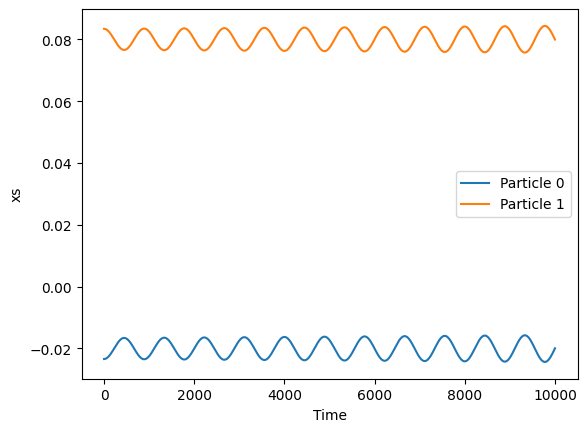

positions [[0.4081128851953352, 0.004686855817390256], [0.4081128851953352, 0.004686855817390256], [0.4081002995446007, 0.004699441468124705], [0.4080751282431318, 0.004724612769593603], [0.408037371920211, 0.004762369092514412], [0.4079870318344034, 0.0048127091783220595], [0.40792410987352506, 0.0048756311392003995], [0.4078486085545803, 0.004951132458145141], [0.4077605310236672, 0.005039209989058242], [0.4076598810558517, 0.005139859956873753], [0.40754666305501036, 0.0052530779577151295], [0.4074208820536415, 0.00537885895908398], [0.4072825437126452, 0.005517197300080263], [0.40713165432107157, 0.0056680866916539105], [0.4069682207958376, 0.005831520216887872], [0.4067922506814129, 0.006007490331312568], [0.4066037521494737, 0.006195988863251739], [0.4064027339985258, 0.006397007014199662], [0.4061892056534957, 0.00661053535922974], [0.405963177165291, 0.006836563847434427], [0.40572465921032896, 0.00707508180239647], [0.40547366309003396, 0.00732607792269146], [0.405210200730303

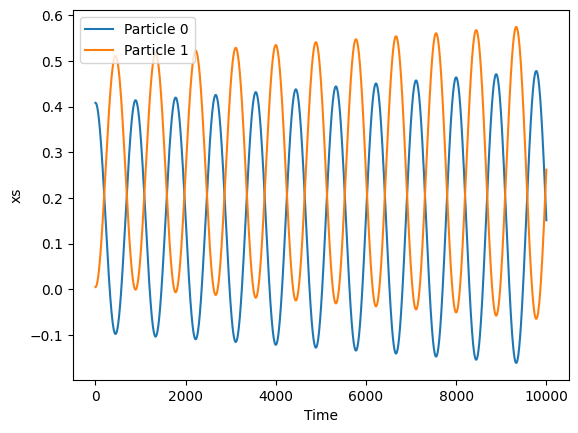

positions [[-0.21816215560029617, 0.25580420415722394], [-0.21816215560029617, 0.25580420415722394], [-0.21815280644130222, 0.25579485499823], [-0.21813410812331435, 0.2557761566802421], [-0.2181060611137905, 0.25574810967071826], [-0.21806866634764654, 0.2557107149045743], [-0.218021925227233, 0.2556639737841607], [-0.2179658396222881, 0.25560788817921587], [-0.21790041186986794, 0.25554246042679574], [-0.21782564477425276, 0.2554676933311805], [-0.21774154160683015, 0.2553835901637579], [-0.21764810610595492, 0.25529015466288263], [-0.21754534247678542, 0.25518739103371313], [-0.21743325539109667, 0.2550753039480244], [-0.21731184998707018, 0.2549538985439979], [-0.2171811318690602, 0.25482318042598795], [-0.21704110710733696, 0.2546831556642647], [-0.21689178223780634, 0.2545338307947341], [-0.2167331642617064, 0.2543752128186342], [-0.21656526064528067, 0.25420730920220846], [-0.21638807931942794, 0.2540301278763557], [-0.21620162867932902, 0.2538436772362568], [-0.2160059175840502

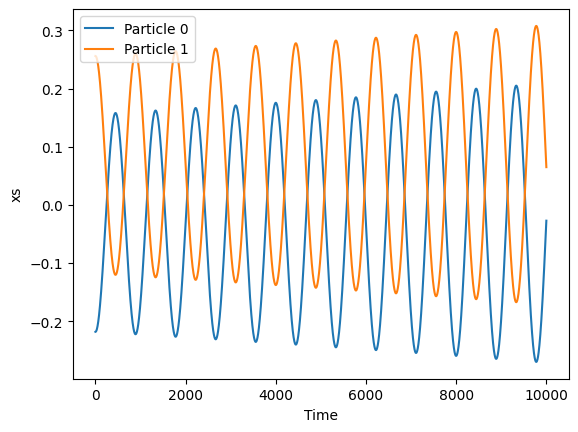

positions [[0.11836899667533163, -0.24949365863755946], [0.11836899667533163, -0.24949365863755946], [0.1183573001089488, -0.24948196207117662], [0.11833390697618316, -0.24945856893841098], [0.11829881786186301, -0.24942347982409083], [0.118252033935645, -0.2493766958978728], [0.11819355695198484, -0.24931821891421266], [0.11812338925007884, -0.24924805121230667], [0.11804153375377618, -0.249166195716004], [0.11794799397146197, -0.2490726559336898], [0.117842773995911, -0.24896743595813883], [0.11772587850411241, -0.24885054046634025], [0.11759731275706498, -0.2487219747192928], [0.11745708259954328, -0.2485817445617711], [0.11730519445983467, -0.24842985642206247], [0.11714165534944702, -0.24826631731167484], [0.11696647286278733, -0.24809113482501516], [0.11677965517681112, -0.24790431713903893], [0.1165812110506427, -0.24770587301287053], [0.1163711498251664, -0.24749581178739422], [0.1161494814225885, -0.24727414338481632], [0.1159162163459703, -0.2470408783081981], [0.115671365678

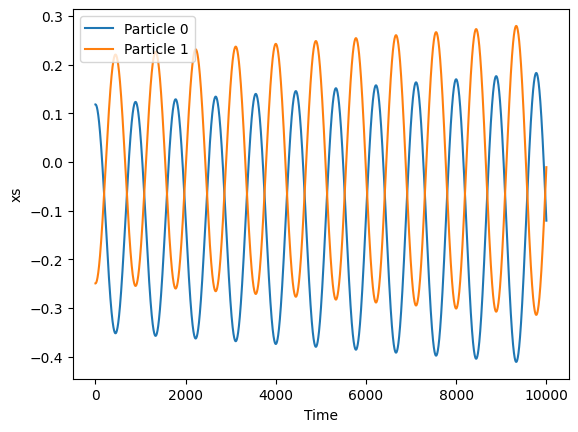

positions [[0.4097462559682401, 0.4827854760376531], [0.4097462559682401, 0.4827854760376531], [0.40974558194874183, 0.48278615005715136], [0.4097442339097453, 0.4827874980961479], [0.40974221188495147, 0.48278952012094173], [0.40973951594176233, 0.48279221606413086], [0.40973614618127907, 0.4827955858246141], [0.40973210273829885, 0.48279962926759434], [0.40972738578130974, 0.48280434622458346], [0.40972199551248384, 0.48280973649340936], [0.40971593216766905, 0.48281579983822415], [0.4097091960163788, 0.4828225359895144], [0.40970178736178026, 0.48282994464411294], [0.40969370654068105, 0.48283802546521215], [0.4096849539235139, 0.4828467780823793], [0.4096755299143199, 0.4828562020915733], [0.4096654349507298, 0.4828662970551634], [0.4096546695039442, 0.482877062501949], [0.40964323407871117, 0.482888497927182], [0.40963112921330314, 0.48290060279259006], [0.40961835547949127, 0.4829133765264019], [0.40960491348251893, 0.48292681852337427], [0.4095908038610727, 0.4829409281448205], 

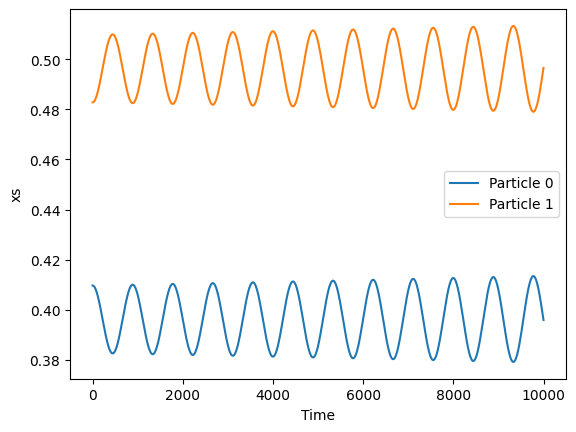

positions [[0.31021723599658957, 0.4021659504395827], [0.31021723599658957, 0.4021659504395827], [0.31021703471445067, 0.4021661517217216], [0.3102166321501728, 0.40216655428599946], [0.31021602831382017, 0.4021671581223521], [0.3102152232255209, 0.40216796321065135], [0.31021421691546686, 0.4021689695207054], [0.31021300942391244, 0.4021701770122598], [0.31021160080117316, 0.4021715856349991], [0.3102099911076236, 0.40217319532854867], [0.31020818041369486, 0.4021750060224774], [0.3102061687998716, 0.40217701763630065], [0.3102039563566886, 0.40217923007948364], [0.31020154318472654, 0.40218164325144573], [0.3101989293946075, 0.40218425704156474], [0.3101961151069902, 0.4021870713291821], [0.310193100452564, 0.4021900859836083], [0.31018988557204336, 0.4021933008641289], [0.310186470616161, 0.40219671582001126], [0.31018285574566096, 0.4022003306905113], [0.310179041131291, 0.40220414530488124], [0.3101750269537947, 0.4022081594823776], [0.3101708134039027, 0.4022123730322696], [0.310

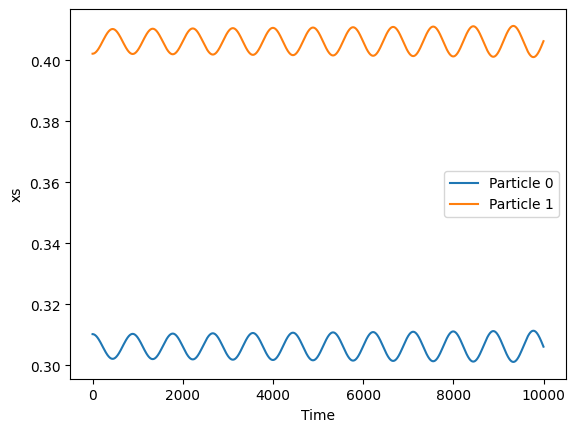

In [123]:
for i in range(10):
    plot_graph(df, i)